# TL;DR
A model to predict residual load (non-renewable electric power) requirements to achieve grid stability for Luxembourg (CREOS). Improving the forecast enable reduced expenses and emissions as running hour of power plants can be planned ahead more accurately. <br>
Consists of 4 parts: (1) Data collection, basic error correction and data staging. Result is a raw csv file for data processing <br>
(2) Data Understanding and resulting transformation, augmentation and preparation operations <br>
(3) Data modeling and model evaluation <br>
(4) Benchmark against the official prediction by SMARD(Bundesnetzagentur)

# 0 Required Libraries

In [ ]:
pip install pandas numpy scipy scikit-learn xgboost lightgbm matplotlib joblib

# 1 Data Preparation

## 1.1 Imports for Data Collection

In [1]:
import numpy as np
import os
import pandas as pd
# import requests
from datetime import datetime
import holidays
# import time

## 1.2 Data collection

### 1.2.1 Weather data Collection (Agrimeteo)

#### Weather Parameters (all hourly)

| Parameter | Description | Type |
| --- | --- | --- |
| **temp** | mean air temperature (in °C) | Float |
| **prcp** | precipitation total (in mm) | Float |
| **wspd** | average wind speed (in m/s) | Float |
| **wpgt** | peak wind gust speed (in km/h) | Float |
| **tsun** | normalized one hour sunshine total (in min/60) | Integer |
| **srad** | solar energy density - total energy per area (in Wh/(m²)) | Integer |

---

#### List of Stations

| Station Code | Location |
| --- | --- |
| 001 | Reuler |
| 003 | Echternach |
| 005 | Oberkorn |
| 006 | Useldange |
| 009 | Remich |
| 012 | Grevenmacher |
| 016 | Eschdorf |
| 023 | Waldbillig |
| 038 | Luxembourg-City |

#### List of Stations by Alphabet
| Station Code | Location |
| --- | --- |
| 003 | Echternach |
| 016 | Eschdorf |
| 012 | Grevenmacher |
| 038 | Luxembourg-City |
| 005 | Oberkorn |
| 009 | Remich |
| 001 | Reuler |
| 006 | Useldange |
| 023 | Waldbillig |

In [ ]:
# Importing the weather data from csv files located  in the ./data_agrimeteo/ folder, combining weather stations for the timespan and formatting it subsequently
WEATHERDATA_PATH = "./data_agrimeteo/" # relative data path for the weather station csv files. adapt as required for individual storage

weather_years = ['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
weather_station_codes = ['001', '003', '005', '006', '009', '012', '016', '023'] 

new_weather_col_names = {
    'AVG_TA200': 'temp',
    'AVG_WV1000': 'wspd',
    'MAX_WV1000max': 'wpgt',
    'SUM_NN050': 'prcp',
    'SUM_SSD': 'tsun',
    'SUM_GS200': 'srad',
}

station_dataframes = {}

for station in weather_station_codes:
    station_yrs = []
    
    for year in weather_years:
        filename = f"{station}_{year}.csv"
        full_path = os.path.join(WEATHERDATA_PATH, filename)
        
        if os.path.exists(full_path):
            df_file = pd.read_csv(full_path, sep=";") 
            
            # format datetime to international format
            df_file['timestamp'] = pd.to_datetime(df_file['Tag'] + ' ' + df_file['Stunde'], format='%d.%m.%Y %H:%M')
            df_file.set_index('timestamp', inplace=True)
            
            # weather data is offered in UTC without the UTC time zone tag
            df_file.index = df_file.index.tz_localize('UTC')
            
            # keep only desired information and rename feature columns
            weather_cols = list(new_weather_col_names.keys())
            df_file = df_file[weather_cols].rename(columns=new_weather_col_names)
            df_file.columns = [f"{station}_{col}" for col in df_file.columns]
            
            station_yrs.append(df_file)
            
    if station_yrs:
        # combine all years for the current station
        combined_station_df = pd.concat(station_yrs, axis=0)
        
        # handling duplicates
        if combined_station_df.index.has_duplicates:
            # identify duplicates and store seperately
            df_duplicates = combined_station_df[duplicate_mask].copy()
            
            # store it explicitly
            df_duplicates['duplicated_timestamp'] = df_duplicates.index
            
            # sort by timestamp so duplicates are next to each othe
            df_duplicates = df_duplicates.sort_index()
            
            print(f"\n Station {station}: Showing all duplicate occurrences:")
            print("-" * 80)
            # Adjusting display options so pandas doesn't truncate our view
            with pd.option_context('display.max_rows', 100, 'display.max_columns', 10):
                print(df_duplicates.head(40))  # Shows the first 20 pairs of duplicates
            print("-" * 80)
            
        
        # handling a case of duplicate entries in the raw csvs according to error pattern
        # Update: has been manually sorted in offered csvs. Will display and correct automatically if more stations or years are added
        if combined_station_df.index.has_duplicates:
            num_dupes = combined_station_df.index.duplicated().sum()
            print(f"Station {station} has {num_dupes} duplicated timestamps. Removing duplicates.")
            
            # Keep the first occurrence and drop subsequent identical timestamps
            # (Alternatively, use keep='last' if you prefer later entries)
            combined_station_df = combined_station_df[~combined_station_df.index.duplicated(keep='last')]
        
        station_dataframes[station] = combined_station_df

# Combining the stations into a joint dataframe
weather_df = pd.concat(station_dataframes.values(), axis=1)

# Sort by time ascending
weather_df.sort_index(inplace=True)

# Converting to international number formatting
weather_df.replace(',', '.', regex=True, inplace=True)

# fixing data types for numeric features
float_endings = ('_temp', '_wspd', '_wpgt', '_prcp', '_tsun', '_srad')
float_cols = [col for col in weather_df.columns if col.endswith(float_endings)]
for col in float_cols:
    weather_df[col] = pd.to_numeric(weather_df[col], errors='coerce')

print("Shape of weather_df:", weather_df.shape)

Shape of final weather_df: (82414, 48)


## 1.2.2 grid data (smard)

In [73]:
# Importing the grid data from csv files located  in the ./data_smard/ folder, combining it for the selected years and subsequent formatting
GRIDDATA_PATH = "./data_smard/" # relative folder containing the source grid load csvs. adapt as required

gridload_years = ['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']

new_grid_col_names = {
    'Netzlast [MWh] Berechnete Auflösungen': 'grid_load',
    'Residuallast [MWh] Berechnete Auflösungen': 'residual_load',
}

# collect all the weather stations in a dict. Later converted to dataframe
grid_df = {}
# Collect a year of data in a list
grid_yrs = []

for year in gridload_years:
    filename = f"LoadLU_{year}.csv"
    full_path = os.path.join(GRIDDATA_PATH, filename)
    
    # check completeness and execute import
    if os.path.exists(full_path):
        # read in csvs, non default seperator
        df_file = pd.read_csv(full_path, sep=";") 
        
        # convert timestamp to international standards
        df_file['timestamp'] = pd.to_datetime(df_file['Datum von'], format='%d.%m.%Y %H:%M')
        df_file.set_index('timestamp', inplace=True)
        
        # map to the Europe/Luxembourg timezone rules, then convert directly to standardized UTC
        df_file.index = df_file.index.tz_localize('Europe/Luxembourg', ambiguous='infer', nonexistent='shift_forward').tz_convert('UTC')

        # keep only desired information and rename
        grid_cols = list(new_grid_col_names.keys())
        df_file = df_file[grid_cols].rename(columns=new_grid_col_names)
        
        # add processed year 
        grid_yrs.append(df_file)

# build power grid information data frame if not empty
if grid_yrs:
    grid_df = pd.concat(grid_yrs, axis=0)

# international number format 
grid_df.replace(',','.',regex=True,
           inplace=True
           )

# convert data type
float_endings = ('grid_load', 'residual_load')
float_cols = [col for col in grid_df.columns if col.endswith(float_endings)]

for col in float_cols:
    grid_df[col] = pd.to_numeric(grid_df[col], errors = 'coerce')


# check for continuity in the grid_df as it requires a complete time frame for joining weather and interpolating
# Create an expected, unbroken hourly range from your data's start to end
expected_range = pd.date_range(start=grid_df.index.min(), end=grid_df.index.max(), freq='h')

if len(expected_range) == len(grid_df.index):
    print("There are zero gaps in the hourly timestamp sequence")
else:
    # define target time span in UTC (is performed similarly later on in code, here for ensuring completeness)
    # target_start = "2017-01-01 00:00:00"
    # target_end   = "2026-05-31 21:00:00"

    perfect_utc_range = pd.date_range(
        start=grid_df.index.min(), 
        end=grid_df.index.max(), 
        freq='h', 
        tz='UTC'
    )   

    # This clips off the late 2016 hour and introduces clean NaN rows for any missing hours.
    grid_df = grid_df.reindex(perfect_utc_range)

    print(" Grid Load Alignment Complete!")

# interpolate missing values
grid_df = grid_df.interpolate(method='cubicspline')

# handling NaN entries at the start or end
grid_df = grid_df.bfill().ffill()


print(f"   • Actual Index Start: {grid_df.index.min()}")
print(f"   • Actual Index End:   {grid_df.index.max()}")
print("Shape of grid_df:", grid_df.shape)

There are zero gaps in the hourly timestamp sequence
   • Actual Index Start: 2016-12-31 23:00:00+00:00
   • Actual Index End:   2026-05-31 21:00:00+00:00
Shape of grid_df: (82511, 2)


## 1.3 Combine data sources and create raw data truth

In [74]:
# Joining the two data frames. RIGHT JOIN weather_df into the grid_df keeps perfect timeline
full_df = weather_df.join(grid_df, how='right')

print(f"Integrated Dataframe Row Count: {len(full_df)}")

# define columns by origin to print out missing value numbers
grid_cols = list(grid_df.columns)
weather_cols = [col for col in full_df.columns if col not in grid_cols]

# calculate gaps
grid_nans = full_df[grid_cols].isna().sum().sum()
weather_nans = full_df[weather_cols].isna().sum().sum()
total_nans = full_df.isna().sum().sum()
maximum_nans = full_df.isna().sum().max()

print("\n Raw data completeness:")
print(f"   • Total missing values in Grid columns:    {grid_nans}")
print(f"   • Total missing values in Weather columns: {weather_nans}")
print(f"   • Grand Total NaN values across matrix:    {total_nans}")
print(f"   • Highest amount of missing values in a single column:    {maximum_nans}")
print(" Dataframe merged and preserved with gaps for cleanup at a later stage")

Integrated Dataframe Row Count: 82511

 Raw data completeness:
   • Total missing values in Grid columns:    0
   • Total missing values in Weather columns: 42245
   • Grand Total NaN values across matrix:    42245
   • Highest amount of missing values in a single column:    3552
 Dataframe merged and preserved with gaps for cleanup at a later stage


In [75]:
# Name the index explicitely to avoid loading errors
full_df.index.name = 'timestamp'
full_df.to_csv("./full_dataset/dataset_raw.csv")

# 2 Data Modeling 
## 2.1 Imports

In [2]:
# List of imports for processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
import joblib
from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit,
)   
from sklearn.metrics import (
    r2_score,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    )   
from sklearn.preprocessing import (
    MinMaxScaler, 
    StandardScaler, 
    RobustScaler, 
    OneHotEncoder, 
    OrdinalEncoder
)   
from sklearn.ensemble import (
    # RandomForestRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
)
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer

import lightgbm as lgb
import xgboost as xgb

from ydata_profiling import ProfileReport

from sklearn import set_config
set_config(transform_output="pandas")

C:\Users\luk3\AppData\Local\Temp\ipykernel_24704\17090661.py:40: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## 2.2 Data exploration
Create overview of corrs for the input data within a class to filter if data reduction can be performed. Creating a full corr table for all 50 features breaks ProfileReport.
Features are:
- temperatur in °C ('temp')
- average wind speed in m/s ('wspd')
- wind gust top speed in m/s ('wpgt')
- precipitation in mm ('prcp')
- sunshine duration in min during a full hour ('tsun')
- accumulated solar radiation energy density in Wh/m^2 ('srad')

### 2.2.1 Profile report creation

In [3]:
# Import in case chapter 1 is already performed and needs no duplicate execution
full_df = pd.read_csv('./full_dataset/dataset_raw.csv',
                      index_col = 'timestamp',
                      parse_dates = True)

In [ ]:
# Create Profile Reports within seperate variables and to the target variable. Saved in html files in the folder containing the ipynb
feature_dict = {
    'temp': 'temperature in °C',
    'wspd': 'average wind speed in m/s',
    'wpgt': 'wind gust top speed in m/s',
    'prcp': 'precipitation in mm',
    'tsun': 'sunshine duration in min during a full hour',
    'srad': 'accumulated solar radiation energy density in Wh/m^2'
}

# select the target variable column name
target_var = 'residual_load'

for key in feature_dict.keys():
    # filter the columns that display the same feature
    temp_cols = [col for col in full_df.columns if col.endswith(f'_{key}')]

    if target_var in full_df.columns:
        temp_cols.append(target_var)
    else:
        print(f"Warning: {target_var} not found in the DataFrame!")
    
    df_temp = full_df[temp_cols]

    # create profilereport for selected feature in different stations
    profile_temp = ProfileReport(df_temp, title=f"Correlations for {feature_dict[key]} & residual load in Luxemburg")
    profile_temp.to_file(f"report_{key}_correlation.html")

### 2.2.2 Exploration findings and takeaways
- Very high correlations in temperature + solar energy density (>.9):  Calculate region mean and standard deviation to signal incoming temperature+energy surges/dips
- Mostly mid correlations between avg wind speeds and very low neg. corr. with target (-.05 > corr > -.2). Keeping all of them could be beneficial, but didn't move the needle in experiments. Wind energy is not that dominant in Luxembourg. Keeping a regional average and an engineered feature to account for P~v³ physics law for wind turbines has been chosen.
- Mid to high corrs (Between .5 to .8) between peak wind speeds, precipitation and relative sunshine per hour combined with low correlation with the target. Regional mean and max values are used therefore.

## 2.3 Feature modeling and data augmentation

### 2.3.1 Numerical features

In [ ]:
# Calculating predictive features based on statistical decision making and feature engineering
weather_features = ['temp', 'srad', 'prcp', 'tsun', 'wpgt', 'wspd']
df_features = pd.DataFrame(index=full_df.index)

# Calculating statistical aggregates as estimates for key weather features
for feat in weather_features:
    feat_cols = [col for col in full_df.columns if col.endswith(f"_{feat}")]
    if not feat_cols:
        continue
        
    if feat in ['temp', 'srad']:
        df_features[f'{feat}_mean'] = full_df[feat_cols].mean(axis=1)
        df_features[f'{feat}_std'] = full_df[feat_cols].std(axis=1)
        
    elif feat in ['prcp', 'wpgt', 'tsun']:
        df_features[f'{feat}_mean'] = full_df[feat_cols].mean(axis=1)
        df_features[f'{feat}_max'] = full_df[feat_cols].max(axis=1)

    elif feat == 'wspd':
        df_features['wspd_mean'] = full_df[feat_cols].mean(axis=1)

# interpolate missing values
df_features = df_features.interpolate(method='cubicspline')

# handling NaN entries at the start or end
df_features = df_features.bfill().ffill()

# physics-based wind turbine power curve. uses P~v³ for wind turbines up to a cap of 12 m/s
WIND_CAP = 12 
wspd_capped = df_features['wspd_mean'].clip(upper=WIND_CAP)
df_features['wind_nrg_potential'] = wspd_capped ** 3

# weighing radiation with cloud coverage helps account for partial solar panel shading drops on string inverters
# also reduces necessary tree depth with vertical splitting rules
df_features['weighted_srad'] = df_features['srad_mean'] * df_features['tsun_mean']

# cutting off the top left trapezoid structure from temperature residual load interaction chart
# feature accounts for rising amount of installed heat pumps
df_features['heating_demand_indicator'] = (15 - df_features['temp_mean']).clip(lower=0)


# engineer regressive feature for residual load from 1 day and 1 week earlier
df_features['residual_load_lag_1d'] = full_df['residual_load'].shift(24)
df_features['residual_load_lag_7d'] = full_df['residual_load'].shift(168)

# SET ASIDE FOR BENCHMARK USABILTIY BUT WOULD BE USED TO IMPROVE LIVE PREDICTIONS
# The within day feedback loop heavily skews comparisons with the benchmark as this is performed 24h-48h ahead with forecast data
# df_features['residual_load_lag_3h_smoothed'] = full_df['residual_load'].shift(1).rolling(3).mean()

# Cleaning up edge effects now done using time cutoff. 
# clean up edge effects when using regressive residual load prediction
df_features.dropna(subset=['residual_load_lag_7d'], inplace=True)
df_features

print(f"Remaining missing values in entire feature set: {df_features.isna().sum().sum()}")
print(f"Dataset shape (rows, cols): {df_features.shape}")

Remaining missing values in entire feature set: 0
Dataset shape (rows, cols): (82343, 16)


### 2.3.2 Categorical features

In [6]:
# Augment the dataset by creating country specific variables of society specific calendar concepts like day of the week, workdays, weekends, holidays and gap days
# find all years in dataset
all_years = df_features.index.year.unique()
# collect a list of holidays for the time span
holidays_LU = holidays.Luxembourg(all_years)
# Normalize index to check calendar dates without time component
normalized_dates = df_features.index.normalize()

# create column for holidays
df_features['is_holiday'] = normalized_dates.isin(holidays_LU).astype(int)
# column for Monday = 0, Tuesday = 1, ... , Sunday = 6 (int type)
df_features['weekday'] = df_features.index.dayofweek
# column for weekends
df_features['is_weekend'] = (df_features['weekday'] >= 5).astype(int)
# column for workdays (Mon through Fri which are not holidays)
df_features['workday'] = ((df_features['weekday'] < 5) & (df_features['is_holiday'] == 0)).astype(int)

# calculate gap days ("Brückentag"). 
holiday_dates = df_features[df_features['is_holiday'] == 1].index.normalize().unique()
# Generate chronological targets for days immediately preceding or following a holiday
days_after_holiday = holiday_dates + pd.Timedelta(days=1)
days_before_holiday = holiday_dates - pd.Timedelta(days=1)
# Check which index rows align with those boundary days
is_day_after_holiday = normalized_dates.isin(days_after_holiday)
is_day_before_holiday = normalized_dates.isin(days_before_holiday)
# Gap Day Logic:
# - A Friday (4) that follows a Thursday holiday
# - A Monday (0) that precedes a Tuesday holiday
# day in question must be a workday as well to account for subsequent holidays
df_features['is_gapday'] = (
    (df_features['workday'] == 1) & (
        ((df_features['weekday'] == 4) & is_day_after_holiday) | 
        ((df_features['weekday'] == 0) & is_day_before_holiday)
    )
).astype(int)

# basic calendaric features
df_features['hour'] = df_features.index.hour
df_features['day'] = df_features.index.day
df_features['month'] = df_features.index.month

# Numerical feature exception: calculate absolute time distance from astronomical noon (12:30 UTC / 12.5)
df_features['solar_noon_distance'] = np.minimum(11.5, (12.5 - df_features['hour']).abs())

print(f"Calendar processing complete! Feature array updated.")
df_features[['month', 'hour', 'is_holiday', 'weekday', 'workday', 'is_weekend', 'is_gapday']].head()

Calendar processing complete! Feature array updated.


C:\Users\luk3\AppData\Local\Temp\ipykernel_32852\2855243175.py:10: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns, UTC] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_features['is_holiday'] = normalized_dates.isin(holidays_LU).astype(int)


,month,hour,is_holiday,weekday,workday,is_weekend,is_gapday
timestamp,,,,,,,
2017-01-07 23:00:00+00:00,1,23,0,5,0,1,0
2017-01-08 00:00:00+00:00,1,0,0,6,0,1,0
2017-01-08 01:00:00+00:00,1,1,0,6,0,1,0
2017-01-08 02:00:00+00:00,1,2,0,6,0,1,0
2017-01-08 03:00:00+00:00,1,3,0,6,0,1,0


# 3 Modeling + Evaluation

## 3.1 Pipeline

In [7]:
# convert categorical feature datatype to string to fit my cateogorical pipeline
df_features['weekday'] = df_features['weekday'].astype(str)
df_features['is_holiday'] = df_features['is_holiday'].astype(str)
df_features['is_weekend'] = df_features['is_weekend'].astype(str)
df_features['workday'] = df_features['workday'].astype(str)
df_features['is_gapday'] = df_features['is_gapday'].astype(str)
df_features['hour'] = df_features['hour'].astype(str)
df_features['month'] = df_features['month'].astype(str)
df_features['day'] = df_features['day'].astype(str)

In [8]:
# Make sure your index is explicitly sorted chronologically
df_features = df_features.sort_index()
full_df = full_df.sort_index()

# Setup for modeling processed data
y_all = full_df['residual_load']
X_all = df_features

# Validation timeslice
X_val = X_all.loc['2025-06-01':'2026-05-31']
y_val = y_all.loc['2025-06-01':'2026-05-31']

# Training timeslice
X_train = X_all.loc['2017-01-08':'2025-05-31']
y_train = y_all.loc['2017-01-08':'2025-05-31']

# Verify the chronological split shape
print(f"Training data shape (Jan 2017- May 2025):   {X_train.shape}")
print(f"Validation data shape (June 2025 - May 2026): {X_val.shape}")

Training data shape (Jan 2017- May 2025):   (73584, 25)
Validation data shape (June 2025 - May 2026): (8758, 25)


In [9]:
# pipeline for categorical and ordinal features. Ordinal features havent been selected for analysis, but doesnt impact to carry dead weight
ord_feat = []
categories = []
ord_encoder = OrdinalEncoder(categories=categories)

# Preparinging the categorical imputer and one-hot-encoder
# cat_imputer = SimpleImputer(strategy='constant', fill_value='N_A') # Imputing not necessary due to data cleaning
oh_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# # # Combining ordinal and one-hot encoder for joint categorical handling
# Select only non-numerical columns
cat_feat = X_train.select_dtypes(exclude="number").columns
# Select categorical columns that are not ordinal
oh_feat = list(set(cat_feat) - set(ord_feat))
# initialize the column transformer to apply enconders to the categorical columns seperately for purely categorical and ordinal data
encoder = make_column_transformer(
    (ord_encoder, ord_feat),
    (oh_encoder, oh_feat)
)
# 
# # # Finalize categorical data handling by creating a pipeline
cat_pipe = make_pipeline(
    # cat_imputer,
    encoder
)

# creating numerical pipeline. Scaler selection at a later stage, therefore left out in this setup
num_feat = X_train.select_dtypes(include="number").columns
num_imputer = SimpleImputer()
# num_scaler = MinMaxScaler()
num_pipe = make_pipeline(
                        num_imputer,
                        # num_scaler,
                        )

# Create preprocessor for the entire dataset split in numerical and categorical data
preprocessor = make_column_transformer(
    (num_pipe, num_feat),
    (cat_pipe, cat_feat)
)
preprocessor

,transformers,"[('pipeline-1', ...), ('pipeline-2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


## 3.2 Randomized Search and Validation

In [ ]:
# Define the models
models = {
    'XGBoost': xgb.XGBRegressor(random_state=7353),
    'LightGBM': lgb.LGBMRegressor(random_state=7353),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=7353)
}

# The list of scalers to evaluate dynamically in the pipeline
scalers_to_try = [MinMaxScaler(), RobustScaler(), StandardScaler()]

param_grids = {
    'XGBoost': {
        'scaler': scalers_to_try,
        'xgbregressor__n_estimators': stats.randint(100, 600),
        'xgbregressor__max_depth': stats.randint(4, 12),
        'xgbregressor__learning_rate': stats.loguniform(0.01, 0.15),
        'xgbregressor__subsample': stats.uniform(0.7, 0.3),
        'xgbregressor__colsample_bytree': stats.uniform(0.7, 0.3)
    },
    
    'LightGBM': {
        'scaler': scalers_to_try,
        'lgbmregressor__n_estimators': stats.randint(100, 500),
        'lgbmregressor__max_depth': [-1, 3, 5, 8, 10, 12],
        'lgbmregressor__learning_rate': stats.loguniform(0.01, 0.15),
        'lgbmregressor__num_leaves': stats.randint(15, 80),
        'lgbmregressor__n_jobs': [1],
    },
    
    'HistGradientBoosting': {
        'scaler': scalers_to_try,
        'histgradientboostingregressor__max_iter': stats.randint(100, 500),
        'histgradientboostingregressor__max_depth': [None, 3, 5, 8, 10, 12],
        'histgradientboostingregressor__learning_rate': stats.loguniform(0.01, 0.15),
        'histgradientboostingregressor__max_leaf_nodes': stats.randint(15, 80)
    }
}

In [11]:
def score_model(model_name, y_true, y_pred):
    """
    Evaluates regression performance on the validation set.
    """
    scores = {
        'Model': model_name,
        'MAE (MWh)': round(mean_absolute_error(y_true, y_pred), 2),
        'MedAE (MWh)': round(median_absolute_error(y_true, y_pred), 2),  # Robust to extreme spike anomalies
        'RMSE (MWh)': round(root_mean_squared_error(y_true, y_pred), 2),
        'MAPE (%)': round(100 * mean_absolute_percentage_error(y_true, y_pred), 2),
        'R-Squared': round(r2_score(y_true, y_pred), 3),
    }
    return scores

In [12]:
# automated function to perform a RandomizedSearchCV
def run_ts_random_search(model, preprocessor, X, y, param_distributions, n_iter=15, n_splits=5, n_jobs=-1, verbose=0, random_state=7353):
    """
    Performs a Randomized Search CV for given selection of models. Also requires a parameter grid, number of iterations. 
    """
    ts_cv = TimeSeriesSplit(n_splits=n_splits)
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('scaler', StandardScaler()),  # Default scaler, overwritten by parameter grid
        (f'{model.__class__.__name__.lower()}', model)
    ])
    
    random_search = RandomizedSearchCV(
        estimator=pipe, 
        param_distributions=param_distributions, 
        n_iter=n_iter,             
        cv=ts_cv,                  
        scoring='neg_mean_absolute_error', 
        verbose=verbose, 
        n_jobs=n_jobs,
        random_state=random_state  
    )
    
    random_search.fit(X, y)
    return random_search

In [89]:
# create timestamp reference for this training session
run_time_anchor = datetime.now()
timestamp_folder_name = run_time_anchor.strftime("%Y-%m-%d_%H-%M")
current_timestamp = run_time_anchor.strftime("%Y-%m-%d %H:%M:%S")

# make sure directory is existing or created for result storage
base_models_dir = "exported_models"
models_dir = os.path.join(base_models_dir, timestamp_folder_name)
os.makedirs(models_dir, exist_ok=True)
print(f" Session active. All optimized models will be archived in: {models_dir}")

# list for keeping metric + parameter records
model_scores_list = []

# searching for the best parameter for each selected model 
for model_name, model_obj in models.items():
    print(f"\n Running Randomized Search for {model_name}...")
    
    # search routine with parameters
    search_result = run_ts_random_search(
        model=model_obj,
        preprocessor=preprocessor, 
        X=X_train,
        y=y_train,
        param_distributions=param_grids[model_name],
        n_iter=100,  # Maximizing hyperparameter combinations
        n_splits=5,
        n_jobs=-5,
        verbose=3,
        random_state=43254,
    )
    
    # best pipeline parameters
    best_pipeline = search_result.best_estimator_
    
    # saving the entire pipeline to a file so preprocessing the training doesnt have to be redone for inference and graphical processing
    model_filename = os.path.join(models_dir, f"best_pipeline_{model_name.lower()}.joblib")
    joblib.dump(best_pipeline, model_filename)
    print(f"Saved optimized {model_name} pipeline to: {model_filename}")
    
    # predict against your isolated 2026 validation holdout window
    y_pred = search_result.predict(X_val)
    
    # calculate validation performance metrics
    metrics = score_model(model_name, y_val, y_pred)
    
    # extract and clean up the winning parameter names for the report
    cleaned_params = {}
    for key, val in search_result.best_params_.items():
        clean_key = key.split('__')[-1]
        if hasattr(val, 'fit'):
            cleaned_params[clean_key] = val.__class__.__name__
        else:
            cleaned_params[clean_key] = val
            
    # merge metrics and parameters into a single row
    combined_row = {**metrics, **cleaned_params}
    model_scores_list.append(combined_row)


# Append the results of the Randomized Search to the existing simulation results
# convert the current run's data into a DataFrame
current_run_df = pd.DataFrame(model_scores_list)

# insert time of timestamp of the training process to better keep record of model optimization
current_run_df.insert(0, 'Run_Timestamp', current_timestamp)

# define your target master log file
output_filename = "new_model_validation_performance_report.csv"

if os.path.exists(output_filename):
    print(f"\n Found existing log file. Appending new historical records...")
    # Read the master file as it currently stands
    existing_log_df = pd.read_csv(output_filename)
    
    # Safely combine them even if current_run_df has brand new columns
    combined_master_df = pd.concat([existing_log_df, current_run_df], axis=0, ignore_index=True)
else:
    print(f"\n No existing log found. Creating a fresh master log file...")
    combined_master_df = current_run_df

# standardize column order: Metadata and core scores first, hyperparams last
core_cols = ['Run_Timestamp', 'Model', 'scaler', 'MAE (MWh)', 'MedAE (MWh)', 'RMSE (MWh)', 'MAPE (%)', 'R-Squared']
hyperparam_cols = [c for c in combined_master_df.columns if c not in core_cols]

# keep core metrics structured and sort hyperparameters alphabetically for clean spreadsheet view
final_column_order = core_cols + sorted(hyperparam_cols)
combined_master_df = combined_master_df[final_column_order]

# save the updated history back to the CSV file
combined_master_df.to_csv(output_filename, index=False)

print(f" Multi-model evaluation complete! Total records inside log: {len(combined_master_df)}")
print(f" Leaderboard updated at: '{os.path.abspath(output_filename)}'")

# display just this current run's core scores on screen for quick feedback
display(current_run_df[core_cols])

 Session active. All optimized models will be archived in: exported_models\2026-06-24_09-58

 Running Randomized Search for XGBoost...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Saved optimized XGBoost pipeline to: exported_models\2026-06-24_09-58\best_pipeline_xgboost.joblib

 Running Randomized Search for LightGBM...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,019024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4199
[LightGBM] [Info] Number of data points in the train set: 73584, number of used features: 95
[LightGBM] [Info] Start training from score 481,819510
Saved optimized LightGBM pipeline to: exported_models\2026-06-24_09-58\best_pipeline_lightgbm.joblib

 Running Randomized Search for HistGradientBoosting...
Fitting 5 folds for each of 100

,Run_Timestamp,Model,scaler,MAE (MWh),MedAE (MWh),RMSE (MWh),MAPE (%),R-Squared
0,2026-06-24 09:58:56,XGBoost,StandardScaler,48.23,37.56,63.86,14.05,0.726
1,2026-06-24 09:58:56,LightGBM,StandardScaler,48.45,37.43,64.39,14.28,0.721
2,2026-06-24 09:58:56,HistGradientBoosting,RobustScaler,48.91,38.03,64.92,14.44,0.717


# 4 Benchmark
To add another layer of quality assurance I'm currently working on adding forecast data from ELLX Luxembourg Airport for the next 24h, transform the data to fit the data pipeline expected format and predict. Import the actual and predicted residual load curve for the previous day and plot them for comparison. Append imported data and display updated visuals. Optimally use a cloud scheduler to perform this action at midnight 


## 4.1 Imports

In [13]:
# Read in Model Performance Metrics from previous runs
model_eval_df = pd.read_csv('new_model_validation_performance_report.csv')

In [14]:
# display performance metrics
core_cols = ['Run_Timestamp', 'Model', 'scaler', 'MAE (MWh)', 'MedAE (MWh)', 'RMSE (MWh)', 'MAPE (%)', 'R-Squared']
model_eval_df[core_cols]

,Run_Timestamp,Model,scaler,MAE (MWh),MedAE (MWh),RMSE (MWh),MAPE (%),R-Squared
0,2026-06-17 22:21:11,XGBoost,MinMaxScaler,49.67,39.28,65.62,14.40,0.710
1,2026-06-17 22:21:11,LightGBM,MinMaxScaler,49.64,39.24,65.53,14.43,0.711
2,2026-06-17 22:21:11,HistGradientBoosting,MinMaxScaler,49.75,39.08,65.76,14.51,0.709
3,2026-06-18 08:54:27,XGBoost,RobustScaler,49.91,39.24,65.84,14.44,0.708
4,2026-06-18 08:54:27,LightGBM,MinMaxScaler,49.64,39.24,65.53,14.43,0.711
5,2026-06-18 08:54:27,HistGradientBoosting,MinMaxScaler,49.75,39.08,65.76,14.51,0.709
6,2026-06-18 19:18:33,XGBoost,MinMaxScaler,49.88,39.30,65.77,14.42,0.709
7,2026-06-18 19:18:33,LightGBM,MinMaxScaler,49.64,39.24,65.53,14.43,0.711
8,2026-06-18 19:18:33,HistGradientBoosting,MinMaxScaler,49.75,39.08,65.76,14.51,0.709
9,2026-06-19 08:46:44,XGBoost,RobustScaler,48.92,38.69,64.79,14.23,0.718


In [15]:
# Load the entire serialized pipeline from disk (model_eval_df's Run Timestamp in shape of YYYY-MM-DD_HH-MM) is the folder. 
loaded_pipeline = joblib.load("exported_models/2026-06-24_09-58/best_pipeline_xgboost.joblib")

# Pass raw, unseen future weather data straight into it
# The pipeline automatically scales it, processes it, and generates predictions!
future_predictions = loaded_pipeline.predict(X_val)

In [ ]:
# Import official predictions for validation time frame and clean up entries
GRIDDATA_PATH = "./data_smard/"
filename = "LoadPrognosis_Validation.csv"  # Updated to target the validation file directly
full_path = os.path.join(GRIDDATA_PATH, filename)

new_grid_col_names = {
    'Residuallast [MWh] Berechnete Auflösungen': 'residual_load_officialpred',
}

if os.path.exists(full_path):
    # Load predictions
    officialpred_df = pd.read_csv(full_path, sep=";") 
    
    # Parse the local time column into a native naive datetime index
    officialpred_df['timestamp'] = pd.to_datetime(officialpred_df['Datum von'], format='%d.%m.%Y %H:%M')
    officialpred_df.set_index('timestamp', inplace=True)
    
    # Rename target column
    grid_cols = list(new_grid_col_names.keys())
    officialpred_df = officialpred_df[grid_cols].rename(columns=new_grid_col_names)
    
    # international number formatting (replace commas with decimals)
    # Using a safer approach by selecting the column explicitly to avoid warning side effects
    officialpred_df['residual_load_officialpred'] = (officialpred_df['residual_load_officialpred']
        .astype(str)
        .str.replace(',', '.', regex=False)
    )
    
    # Convert column data to numeric values, forcing invalid text to NaNs
    officialpred_df['residual_load_officialpred'] = pd.to_numeric(officialpred_df['residual_load_officialpred'], 
        errors='coerce'
    )


    # Timezone corrections
    officialpred_df = officialpred_df.tz_localize('Europe/Luxembourg', ambiguous='infer')
    
    # Convert to UTC standard time
    officialpred_df = officialpred_df.tz_convert('UTC')
    
    # Select the benchmark time frame. Should match the validation time frame in 3.1
    start_utc = "2025-06-01 00:00:00"
    end_utc = "2026-05-31 21:00:00"
    officialpred_df = officialpred_df.loc[start_utc:end_utc]
    
    print(" Official SMARD prognosis successfully imported and aligned!")
    print(f"Time-series coverage: {officialpred_df.index.min()} to {officialpred_df.index.max()}")
    print(f"Total rows imported for comparison: {len(officialpred_df)}")

else:
    print(f" Error: The file '{filename}' was not found in path '{GRIDDATA_PATH}'.")

# Preview the formatted result
officialpred_df

 Official SMARD prognosis successfully imported and aligned!
Time-series coverage: 2025-06-01 00:00:00+00:00 to 2026-05-31 21:00:00+00:00
Total rows imported for comparison: 8758


,residual_load_officialpred
timestamp,
2025-06-01 00:00:00+00:00,360.75
2025-06-01 01:00:00+00:00,356.00
2025-06-01 02:00:00+00:00,355.50
2025-06-01 03:00:00+00:00,359.75
2025-06-01 04:00:00+00:00,353.50
...,...
2026-05-31 17:00:00+00:00,370.00
2026-05-31 18:00:00+00:00,410.50
2026-05-31 19:00:00+00:00,417.50


In [18]:
# Check for missing predictions
# Create an expected, unbroken hourly range from your data's start to end
expected_range = pd.date_range(start=officialpred_df.index.min(), end=officialpred_df.index.max(), freq='h')

# Calculate the difference
missing_hours_count = len(expected_range) - len(officialpred_df.index)

print(f"Dataset Start: {officialpred_df.index.min()}")
print(f"Dataset End:   {officialpred_df.index.max()}")
print(f"Expected number of hours: {len(expected_range)}")
print(f"Actual number of rows:    {len(officialpred_df.index)}")

if missing_hours_count == 0:
    print(f" Perfect! There are zero gaps in your hourly timestamp sequence.")
else:
    print(f" Alert: There are {missing_hours_count} missing hourly rows/timestamps in your data!")

Dataset Start: 2025-06-01 00:00:00+00:00
Dataset End:   2026-05-31 21:00:00+00:00
Expected number of hours: 8758
Actual number of rows:    8758
 Perfect! There are zero gaps in your hourly timestamp sequence.


In [ ]:
# Align the official data to match your validation index exactly
# This ensures that any rows dropping out or shifting are mathematically identical
evaluation_df = pd.DataFrame(index=y_val.index)
evaluation_df['Actual_Ground_Truth'] = y_val.values

# Inner join aligns the timestamps perfectly
evaluation_df = evaluation_df.join(officialpred_df['residual_load_officialpred'], how='inner')

# Clean up any missing predictions via interpolation techniques
evaluation_df = evaluation_df.interpolate(method='cubicspline').bfill().ffill()

# Extract aligned vectors
y_true_aligned = evaluation_df['Actual_Ground_Truth'].values
y_official_aligned = evaluation_df['residual_load_officialpred'].values

# Compute metrics for the Official Professional Model
official_metrics = {
    'Model': 'Official SMARD Prognosis',
    'MAE (MWh)': round(mean_absolute_error(y_true_aligned, y_official_aligned), 2),
    'MedAE (MWh)': round(median_absolute_error(y_true_aligned, y_official_aligned), 2),
    'RMSE (MWh)': round(root_mean_squared_error(y_true_aligned, y_official_aligned), 2),
    'MAPE (%)': round(100 * mean_absolute_percentage_error(y_true_aligned, y_official_aligned), 2),
    'R-Squared': round(r2_score(y_true_aligned, y_official_aligned), 3),
}

# Performance metrics
print(" OFFICIAL BENCHMARK MODEL PERFORMANCE:")
print(pd.Series(official_metrics).to_string())

 OFFICIAL BENCHMARK MODEL PERFORMANCE:
Model          Official SMARD Prognosis
MAE (MWh)                         46.11
MedAE (MWh)                       27.25
RMSE (MWh)                         71.1
MAPE (%)                          13.29
R-Squared                          0.66


C:\Users\luk3\AppData\Local\Temp\ipykernel_30456\3463738959.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  plot_df['YearMonth'] = plot_df.index.to_period('M')


 Generating monthly subplots


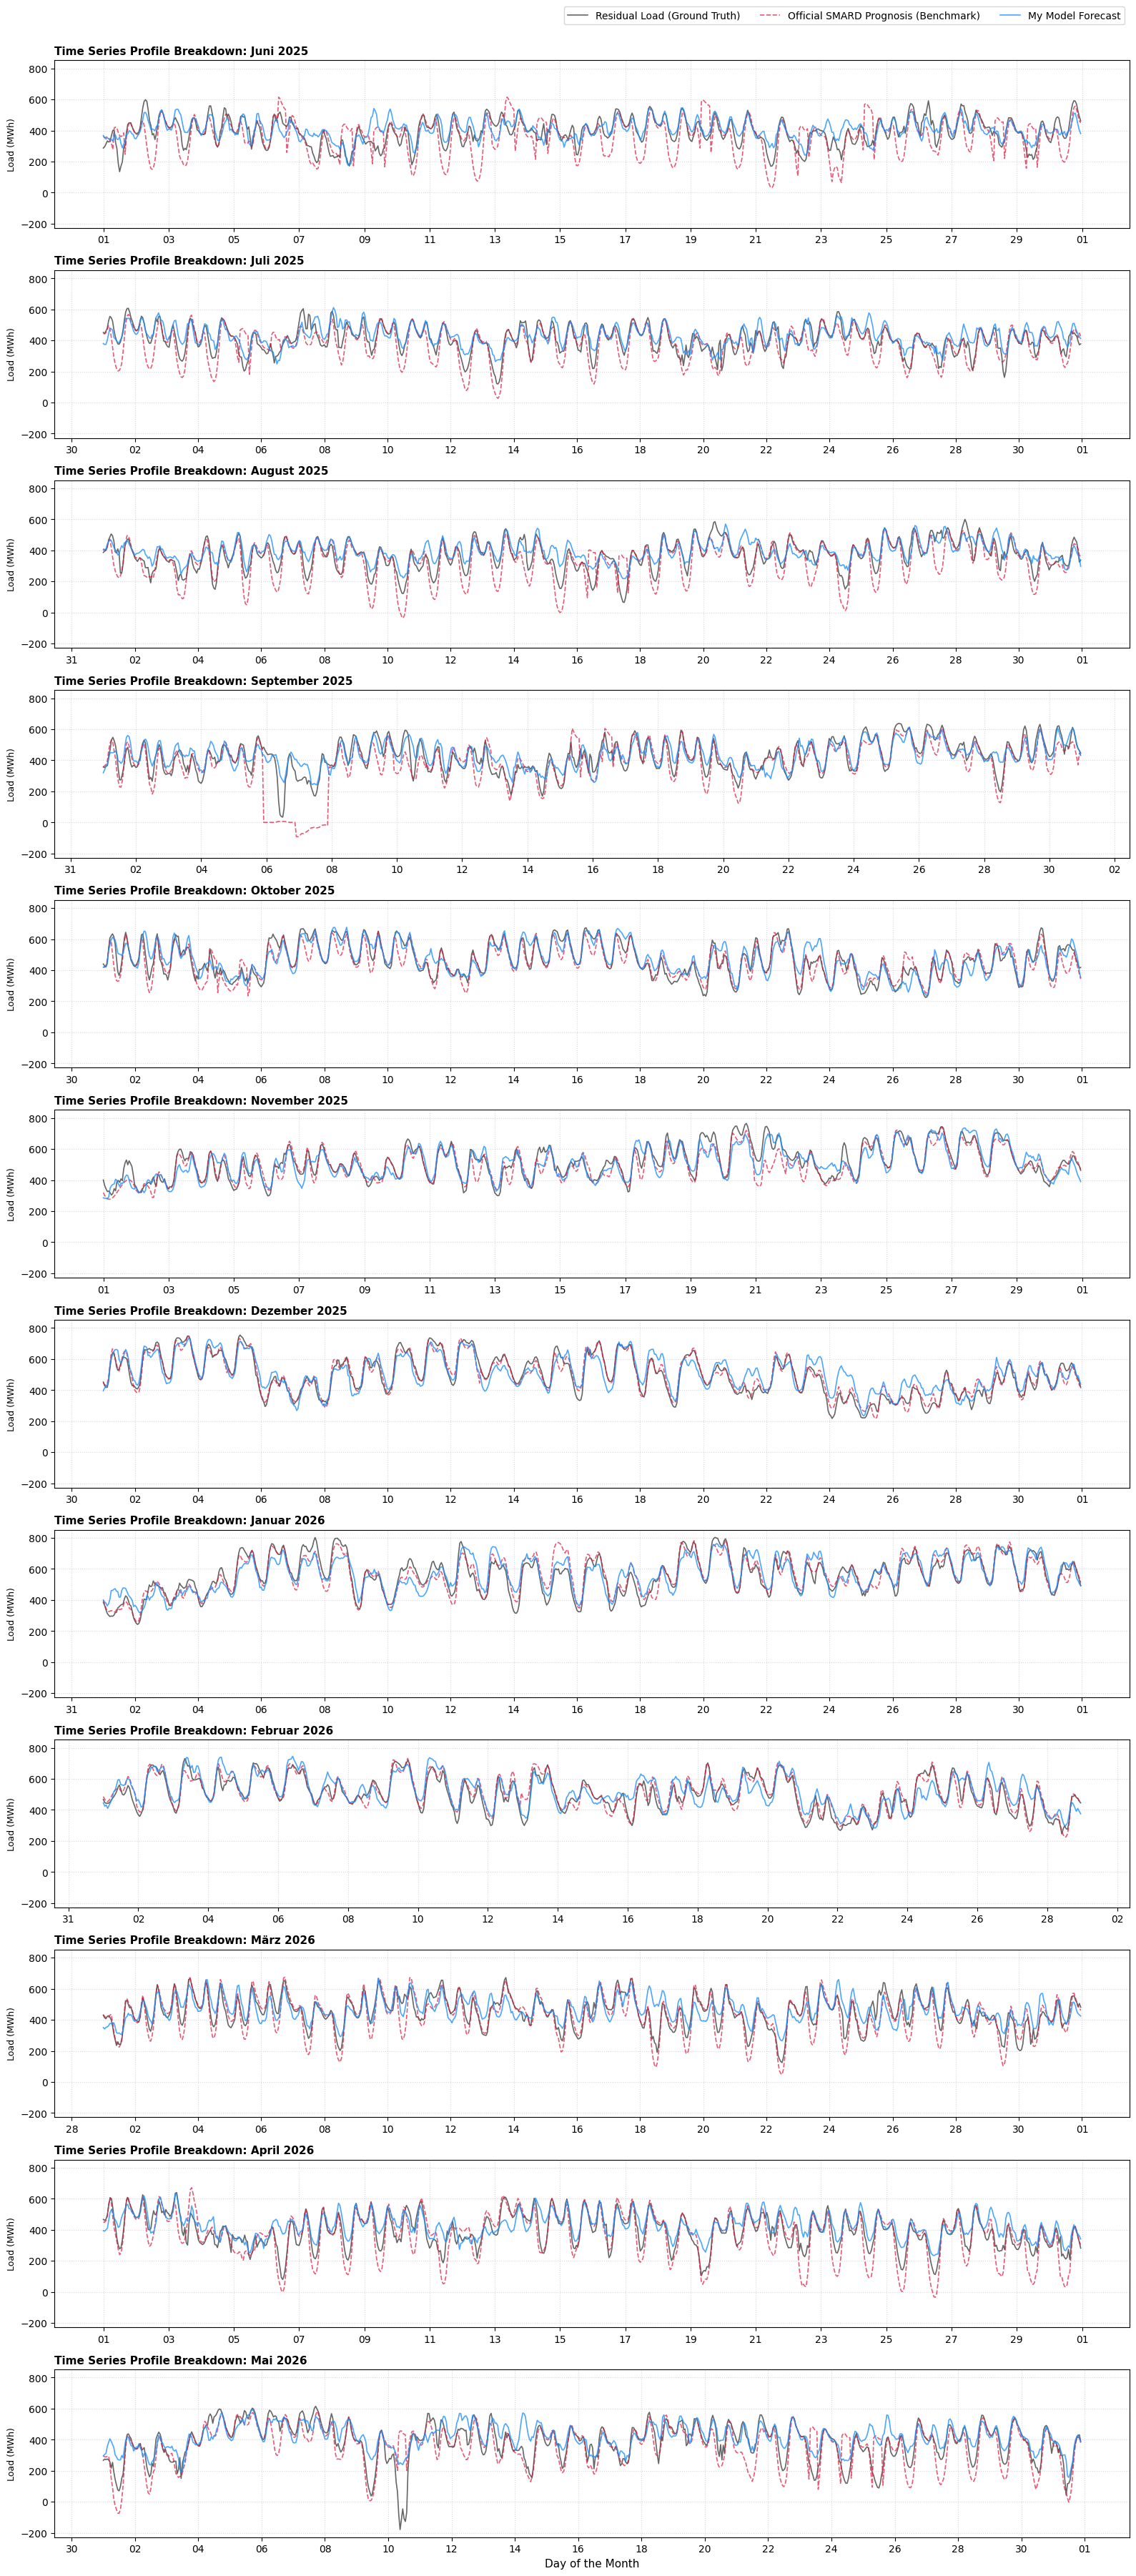

 Generating custom time window: 2026-04-01 00:00:00 to 2026-04-08 00:00:00


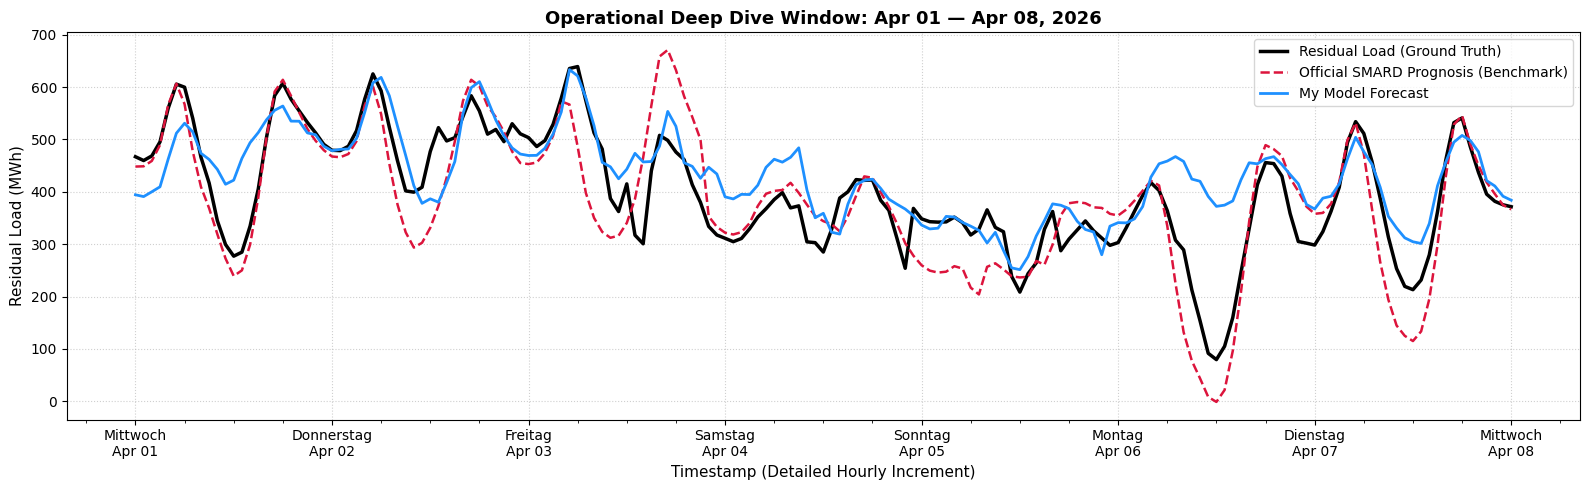

In [ ]:
# Create 2 graphs: one with all months in high resolution and one for a custom time frame
# Following datetime inputs define the custom time frame graph
DEEP_DIVE_START = "2026-04-01 00:00:00"
DEEP_DIVE_END = "2026-04-08 00:00:00"

# Prepare data mapping DataFrame
plot_df = evaluation_df.copy()
plot_df['My_Machine_Learning_Model'] = future_predictions

# Extract unique calendar months present in your validation index
# This dynamically handles whatever timeframe is passed
plot_df['YearMonth'] = plot_df.index.to_period('M')
unique_months = sorted(plot_df['YearMonth'].unique())
num_months = len(unique_months)

# time resolution spans across the entire width of your screen.
fig_m, axes = plt.subplots(num_months, 1, figsize=(16, 3 * num_months), sharey=True, dpi=100)

# Handle edge case if only 1 month is present in the dataset
if num_months == 1:
    axes = [axes]

print(" Generating monthly subplots")
for i, month in enumerate(unique_months):
    ax = axes[i]
    # Slice exact monthly boundaries
    month_df = plot_df[plot_df['YearMonth'] == month]
    
    # Plot target streams
    ax.plot(month_df.index, month_df['Actual_Ground_Truth'], label='Residual Load (Ground Truth)', color='black', alpha=0.6, linewidth=1.2)
    ax.plot(month_df.index, month_df['residual_load_officialpred'], label='Official SMARD Prognosis (Benchmark)', color='crimson', alpha=0.7, linewidth=1.2, linestyle='--')
    ax.plot(month_df.index, month_df['My_Machine_Learning_Model'], label='My Model Forecast', color='dodgerblue', alpha=0.8, linewidth=1.2)
    
    # Styling details for each month
    month_name = month.strftime('%B %Y')
    ax.set_title(f"Time Series Profile Breakdown: {month_name}", fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel("Load (MWh)", fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # Clean x-axis labels to show day numbers
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2)) # Label every 2nd day
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

# Place a consolidated global legend at the very top of the figure grid
axes[0].legend(loc='upper right', bbox_to_anchor=(1.0, 1.35), ncol=3, fontsize=10, frameon=True)
plt.xlabel("Day of the Month", fontsize=11)
plt.tight_layout()
plt.show()

# Create Graph for the custom time frame (inserted in the first line of the field)
print(f" Generating custom time window: {DEEP_DIVE_START} to {DEEP_DIVE_END}")
zoom_df = plot_df.loc[DEEP_DIVE_START:DEEP_DIVE_END]

if zoom_df.empty:
    print(" Deep dive window is empty! Please verify your timestamps match the index format.")
else:
    plt.figure(figsize=(16, 5), dpi=100)
    
    plt.plot(zoom_df.index, zoom_df['Actual_Ground_Truth'], label='Residual Load (Ground Truth)', color='black', linewidth=2.5)
    plt.plot(zoom_df.index, zoom_df['residual_load_officialpred'], label='Official SMARD Prognosis (Benchmark)', color='crimson', linewidth=1.8, linestyle='--')
    plt.plot(zoom_df.index, zoom_df['My_Machine_Learning_Model'], label='My Model Forecast', color='dodgerblue', linewidth=2.0)
    
    # Text metadata
    plt.title(f"Operational Deep Dive Window: {pd.to_datetime(DEEP_DIVE_START).strftime('%b %d')} — {pd.to_datetime(DEEP_DIVE_END).strftime('%b %d, %Y')}", fontsize=13, fontweight='bold')
    plt.xlabel("Timestamp (Detailed Hourly Increment)", fontsize=11)
    plt.ylabel("Residual Load (MWh)", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10, frameon=True)
    
    # High-resolution time tickers showing explicit days and major hours
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%A\n%b %d'))
    plt.gca().xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18])) # Finer ticks for noon and morning peaks
    
    plt.tight_layout()
    plt.show()

C:\Users\luk3\AppData\Local\Temp\ipykernel_32852\1914054458.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  plot_df['YearMonth'] = plot_df.index.to_period('M')


 Generating high-resolution deep dive window: 2025-11-11 00:00:00 to 2025-11-18 00:00:00


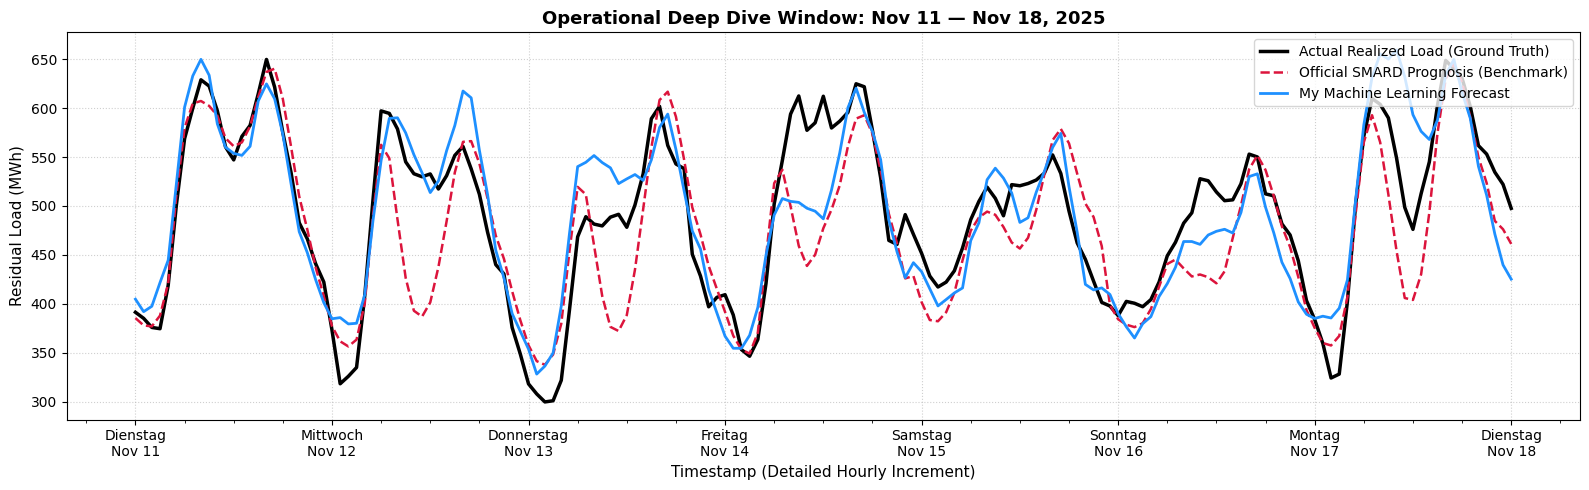

In [20]:
# Create Custom Time Frame only
# Change these values anytime to instantly shift the high-resolution focus window
DEEP_DIVE_START = "2025-11-11 00:00:00"
DEEP_DIVE_END = "2025-11-18 00:00:00"

# Prepare data mapping DataFrame
plot_df = evaluation_df.copy()
plot_df['My_Machine_Learning_Model'] = future_predictions

# Extract unique calendar months present in your validation index
# This dynamically handles whatever timeframe is passed (Jan to May 2026)
plot_df['YearMonth'] = plot_df.index.to_period('M')
unique_months = sorted(plot_df['YearMonth'].unique())
num_months = len(unique_months)

# Create Graph for the custom time frame (inserted in the first line of the field)
print(f" Generating high-resolution deep dive window: {DEEP_DIVE_START} to {DEEP_DIVE_END}")
zoom_df = plot_df.loc[DEEP_DIVE_START:DEEP_DIVE_END]

if zoom_df.empty:
    print(" Deep dive window is empty! Please verify your timestamps match the index format.")
else:
    plt.figure(figsize=(16, 5), dpi=100)
    
    plt.plot(zoom_df.index, zoom_df['Actual_Ground_Truth'], label='Actual Realized Load (Ground Truth)', color='black', linewidth=2.5)
    plt.plot(zoom_df.index, zoom_df['residual_load_officialpred'], label='Official SMARD Prognosis (Benchmark)', color='crimson', linewidth=1.8, linestyle='--')
    plt.plot(zoom_df.index, zoom_df['My_Machine_Learning_Model'], label='My Machine Learning Forecast', color='dodgerblue', linewidth=2.0)
    
    # Text metadata
    plt.title(f"Operational Deep Dive Window: {pd.to_datetime(DEEP_DIVE_START).strftime('%b %d')} — {pd.to_datetime(DEEP_DIVE_END).strftime('%b %d, %Y')}", fontsize=13, fontweight='bold')
    plt.xlabel("Timestamp (Detailed Hourly Increment)", fontsize=11)
    plt.ylabel("Residual Load (MWh)", fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10, frameon=True)
    
    # High-resolution time tickers showing explicit days and major hours
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%A\n%b %d'))
    plt.gca().xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18])) # Finer ticks for noon and morning peaks
    
    plt.tight_layout()
    plt.show()